# 02. Filtering Demo (Frequency Analysis)

## Overview
This notebook demonstrates the signal processing pipeline, specifically **Low-Pass Filtering**. 

EEG signals are often contaminated with high-frequency noise, muscle artifacts (EMG), and power line interference (50 Hz / 60 Hz). 

### Objective
Apply a **40 Hz Low-Pass ButterWorth Filter** to:
1.  Retain neurological bands: Delta (0.5-4Hz), Theta (4-8Hz), Alpha (8-13Hz), Beta (13-30Hz), Low Gamma (30-40Hz).
2.  Eliminate **50 Hz Power Line Noise**.
3.  Reduce high-frequency electromyographic (EMG) noise.

In [6]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.data_processing.loader import load_bonn_data
from src.data_processing.filtering import apply_lowpass_filter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

## 1. Load Data
We load the raw data to compare it before and after filtering.

In [7]:
data_path = os.path.join('..', 'data', 'raw')
X, y = load_bonn_data(data_path)
print(f"Data Loaded: {X.shape}")

Loading 100 files from Z mapped to Class 0...
Loading 100 files from O mapped to Class 0...
Loading 100 files from N mapped to Class 1...
Loading 100 files from F mapped to Class 1...
Loading 100 files from S mapped to Class 2...
Data Loaded: (500, 4097)


## 2. Apply Filtering (40 Hz Low-Pass)
The filtering function uses a 4th order Butterworth filter, applying it forward and backward (`filtfilt`) to avoid phase shifts.

In [8]:
fs = 173.61  # Sampling frequency in Hz
cutoff = 40.0 # Cutoff

X_filtered = apply_lowpass_filter(X, cutoff=cutoff, fs=fs)

## 3. Time Domain Comparison
Visualizing the raw vs filtered signal in the time domain. Note the smoothing effect.

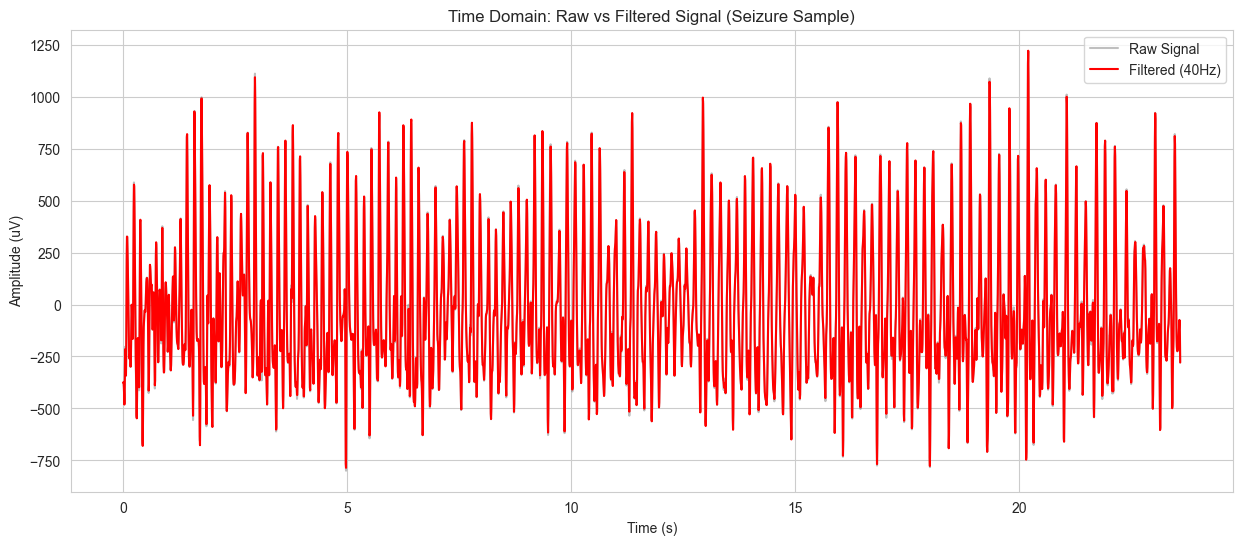

In [9]:
# Pick a Seizure Sample (Class 2) as they have high variability
seizure_indices = np.where(y == 2)[0]
sample_idx = seizure_indices[5]

raw_signal = X[sample_idx]
filtered_signal = X_filtered[sample_idx]
time_axis = np.arange(len(raw_signal)) / fs

plt.figure(figsize=(15, 6))
plt.plot(time_axis, raw_signal, label='Raw Signal', alpha=0.5, color='gray')
plt.plot(time_axis, filtered_signal, label='Filtered (40Hz)', color='red', linewidth=1.5)
plt.title("Time Domain: Raw vs Filtered Signal (Seizure Sample)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")
plt.legend()
plt.show()

## 4. Frequency Domain Analysis (PSD)
The **Power Spectral Density (PSD)** reveals the frequency content of the signal. We expect to see:
1.  A sharp drop in power above 40 Hz in the filtered signal.
2.  Removal of any 50 Hz peaks present in the raw data.

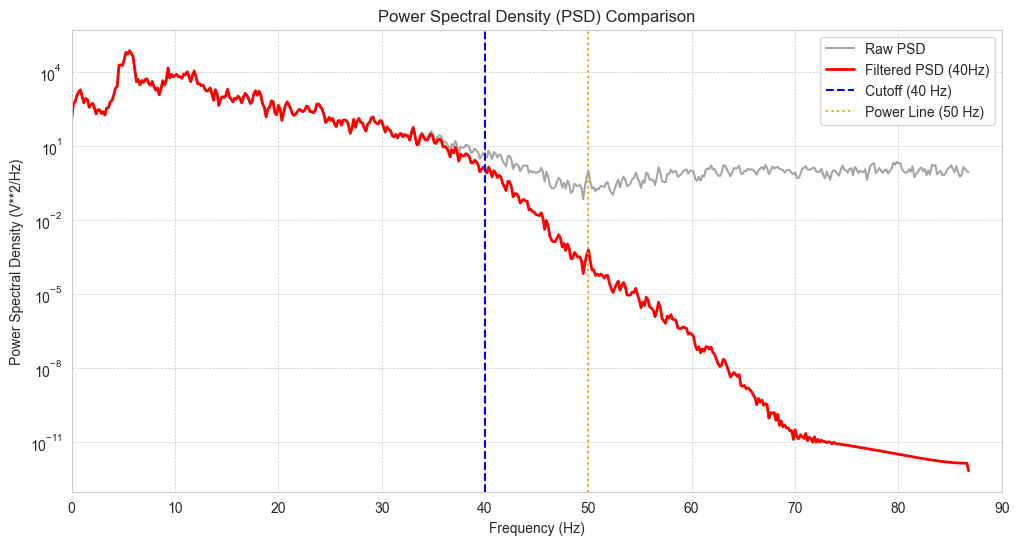

In [10]:
# Compute PSD using Welch's method
f_raw, Pxx_raw = welch(raw_signal, fs, nperseg=1024)
f_filt, Pxx_filt = welch(filtered_signal, fs, nperseg=1024)

plt.figure(figsize=(12, 6))
plt.semilogy(f_raw, Pxx_raw, label='Raw PSD', color='gray', alpha=0.7)
plt.semilogy(f_filt, Pxx_filt, label='Filtered PSD (40Hz)', color='red', linewidth=2)

# Highlight the 40Hz Cutoff
plt.axvline(x=40, color='blue', linestyle='--', label='Cutoff (40 Hz)')
plt.axvline(x=50, color='orange', linestyle=':', label='Power Line (50 Hz)')

plt.title("Power Spectral Density (PSD) Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V**2/Hz)")
plt.legend()
plt.xlim(0, 90) # Focus on relevant range
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

> **Analysis:** The filtered PSD (Red) follows the Raw PSD (Gray) perfectly in the neurological bands (0-40Hz) but drops significantly afterwards, effectively removing high-frequency noise and the 50Hz component.